# Noise Generators

Noise generators produce random signals with controlled spectral distributions. Both functions accept a `seed` for reproducible output.

| Function | Description |
| --- | --- |
| `generate_white_noise` | Uniform random samples scaled to `amplitude`. **Flat power spectral density** — equal power per Hz (or per linear frequency band). The reference noise colour. |
| `generate_pink_noise` | 1/f noise shaped by filtering white noise through a cascade of first-order shelving sections. Power decreases at **−3 dB/octave** — equal power per octave. Perceived as a balanced, "natural" sound. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_pink_noise, generate_white_noise

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Time-domain waveforms and power spectra for both noise generators (500 ms, seed = 42).

**2 × 2 grid:**
- **Top-left — white noise waveform (20 ms):** stationary; all amplitudes are equally likely; no discernible low-frequency structure
- **Top-right — white noise power spectrum:** approximately flat from DC to Nyquist; small frame-to-frame fluctuations are normal (spectral estimation variance)
- **Bottom-left — pink noise waveform (20 ms):** visibly larger low-frequency excursions than white noise; the 1/f shaping concentrates energy in slow swings
- **Bottom-right — pink noise power spectrum:** clear downward slope of approximately −3 dB/octave (the 1/f characteristic); each octave band contains the same total power

Pink noise is the standard stimulus for audio frequency-response measurements because its equal-energy-per-octave property matches the logarithmic frequency perception of human hearing.


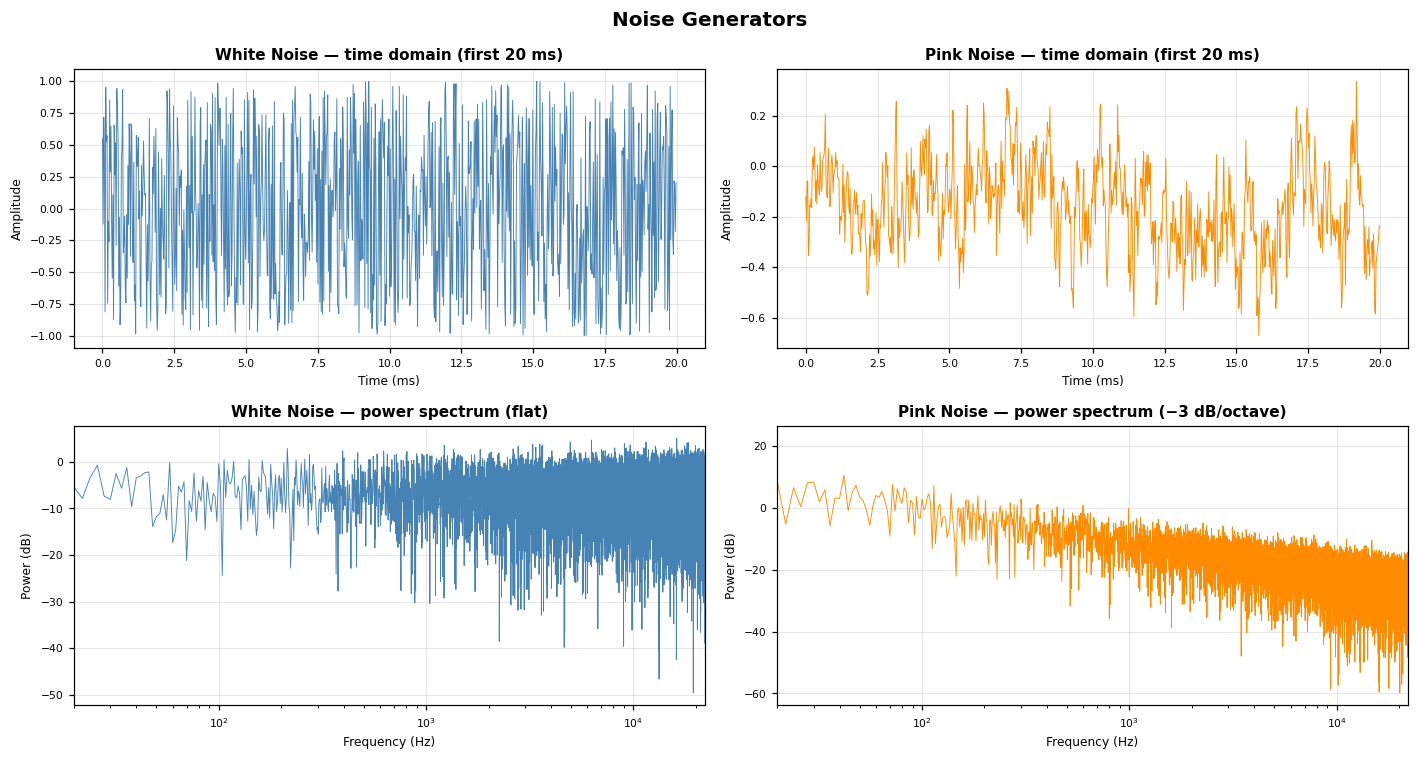

In [2]:
FS = 44100
DURATION = 0.5
SEED = 42

t_white, white = generate_white_noise(fs=FS, duration=DURATION, seed=SEED)
t_pink, pink = generate_pink_noise(fs=FS, duration=DURATION, seed=SEED)


def _power_spectrum(signal: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Return (freqs_hz, power_db) averaged into 1/3-octave-width bins."""
    n = len(signal)
    freqs = np.fft.rfftfreq(n, d=1.0 / FS)
    power = np.abs(np.fft.rfft(signal)) ** 2 / n
    db = 10.0 * np.log10(power + 1e-20)
    return freqs, db


fig, axes = plt.subplots(2, 2, figsize=(13, 7))

WINDOW_MS = 20
n_win = int(WINDOW_MS * FS / 1000)
t_ms = t_white[:n_win] * 1000

# Time domain
axes[0, 0].plot(t_ms, white[:n_win], linewidth=0.6, color="steelblue")
axes[0, 0].set_title("White Noise — time domain (first 20 ms)", fontsize=10, fontweight="bold")
axes[0, 0].set_xlabel("Time (ms)", fontsize=8)
axes[0, 0].set_ylabel("Amplitude", fontsize=8)

axes[0, 1].plot(t_ms, pink[:n_win], linewidth=0.6, color="darkorange")
axes[0, 1].set_title("Pink Noise — time domain (first 20 ms)", fontsize=10, fontweight="bold")
axes[0, 1].set_xlabel("Time (ms)", fontsize=8)
axes[0, 1].set_ylabel("Amplitude", fontsize=8)

# Power spectrum
freqs_w, db_w = _power_spectrum(white)
freqs_p, db_p = _power_spectrum(pink)

mask = freqs_w > 0

axes[1, 0].semilogx(freqs_w[mask], db_w[mask], linewidth=0.6, color="steelblue")
axes[1, 0].set_title("White Noise — power spectrum (flat)", fontsize=10, fontweight="bold")
axes[1, 0].set_xlabel("Frequency (Hz)", fontsize=8)
axes[1, 0].set_ylabel("Power (dB)", fontsize=8)
axes[1, 0].set_xlim(20, FS / 2)

axes[1, 1].semilogx(freqs_p[mask], db_p[mask], linewidth=0.6, color="darkorange")
axes[1, 1].set_title("Pink Noise — power spectrum (−3 dB/octave)", fontsize=10, fontweight="bold")
axes[1, 1].set_xlabel("Frequency (Hz)", fontsize=8)
axes[1, 1].set_ylabel("Power (dB)", fontsize=8)
axes[1, 1].set_xlim(20, FS / 2)

for ax in axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.4, alpha=0.5)

fig.suptitle("Noise Generators", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Spectral Slope Measurement

Pink noise has a theoretical power spectral density of **−3 dB per octave** (power ∝ 1/f).
The cell below measures this slope by:

1. Generating 10 seconds of pink noise (long duration → low variance per band).
2. Computing the one-sided power spectrum via `np.fft.rfft`.
3. Averaging the power across seven 1-octave bands centred at 200 Hz – 12.8 kHz.
4. Fitting a least-squares line in log₂–log₂ space; the slope should be **−1.0** (one power-of-two reduction per octave doubling = −3 dB/octave).

In [ ]:
_, pink_long = generate_pink_noise(fs=FS, duration=10.0, seed=42)

spectrum = np.abs(np.fft.rfft(pink_long)) ** 2
freqs = np.fft.rfftfreq(len(pink_long), d=1.0 / FS)

centers = [200, 400, 800, 1600, 3200, 6400, 12800]
band_freqs, band_powers = [], []
for fc in centers:
    mask = (freqs >= fc / np.sqrt(2)) & (freqs < fc * np.sqrt(2))
    if np.any(mask):
        band_freqs.append(fc)
        band_powers.append(np.mean(spectrum[mask]))

log_f = np.log2(np.array(band_freqs, dtype=float))
log_p = np.log2(np.array(band_powers, dtype=float))
slope, intercept = np.polyfit(log_f, log_p, 1)
slope_db_oct = slope * 10 * np.log10(2)  # log2 slope → dB/octave

fit_f = np.array([centers[0] / 2, centers[-1] * 2], dtype=float)
fit_p = 2 ** (np.polyval([slope, intercept], np.log2(fit_f)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(band_freqs, 10 * np.log10(np.array(band_powers)), color="darkorange",
           zorder=5, label="Octave-band average PSD")
ax.plot(fit_f, 10 * np.log10(fit_p), color="gray", linestyle="--", linewidth=1.0,
        label=f"Best fit: {slope_db_oct:.2f} dB/octave (ideal −3.00)")
ax.set_xscale("log")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power (dB, relative)")
ax.set_title("Pink Noise — Octave-Band PSD Slope")
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.5, which="both")
plt.tight_layout()
plt.show()

print(f"Measured slope: {slope:.4f} (log₂–log₂)  =  {slope_db_oct:.2f} dB/octave")

## Audio Examples

White noise has equal energy per Hz; pink noise has equal energy per octave (warmer).


In [3]:
from IPython.display import Audio, display

_, white_a = generate_white_noise(fs=FS, duration=2.0, seed=0)
_, pink_a  = generate_pink_noise(fs=FS, duration=2.0, seed=0)

print("White noise — equal energy per Hz (bright, hissy)")
display(Audio(white_a * 0.4, rate=FS))
print("Pink noise — equal energy per octave (warmer, more natural)")
display(Audio(pink_a / np.max(np.abs(pink_a)) * 0.5, rate=FS))

White noise — equal energy per Hz (bright, hissy)


Pink noise — equal energy per octave (warmer, more natural)
